IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

EXPLORACIÓN INICIAL

In [2]:
#configuración visual
sns.set_style("whitegrid")

#cargar dataset
df = pd.read_csv(
    r"C:\Users\kencr\OneDrive\Escritorio\GitHub\retail-sales-analysis\data\Sample - Superstore.csv", 
    encoding="latin1"
    )

#ver primeras filas
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
#tamaño del dataset
df.shape

(9994, 21)

In [4]:
#tipos de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
#valores nulos
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
#Estadisticas
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


The initial data exploration revealed a high-quality dataset with complete and unique records, providing a reliable foundation for analysis. Preliminary findings show strong sales performance and positive overall profitability; however, the presence of significant variability in sales and profit values suggests that business results are driven by a limited number of high-value transactions. These patterns highlight the importance of identifying the products, customers, and regions that contribute most to sustainable profitability.

LIMPIEZA DE DATOS

In [7]:
#convertir fechas
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [8]:
#encontrar duplicados
df.duplicated().sum()

np.int64(0)

The data cleaning process confirmed the dataset's strong quality, with no missing values or duplicate records detected. Additionally, date fields were converted to the appropriate format to enable accurate time-based analysis. These preparation steps ensure data consistency, improve analytical reliability, and provide a solid foundation for generating meaningful business insights.

KPIs PRINCIPALES

In [9]:
#ventas totales
total_sales= df["Sales"].sum()
print (total_sales)

2297200.8603


While total sales are strong, revenue alone does not reflect business success. Further analysis should focus on identifying which products, regions, and customer segments contribute the most to profitability, ensuring that sales growth translates into sustainable financial performance.

In [10]:
#ganancia total
total_profit = df["Profit"].sum()
print(total_profit)

286397.0217


Although total profitability is positive, the presence of loss-making transactions suggests that profit is not distributed evenly across the business. Identifying the products, regions, and customer segments that contribute most to profit will be essential for improving overall financial performance and supporting sustainable growth.

In [11]:
#número de ordenes
df["Order ID"].nunique()

5009

A large number of orders indicates consistent customer demand, however, order volume alone does not determine business success. Analyzing the average order value and profitability per order can provide deeper insight into the quality and financial impact of customer transactions.

GRÁFICOS

<function matplotlib.pyplot.show(close=None, block=None)>

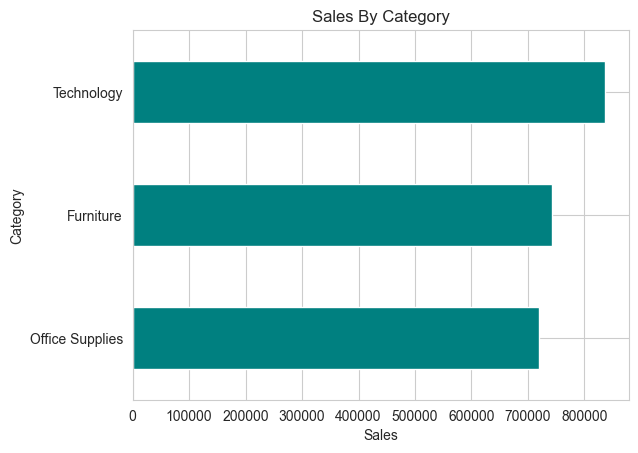

In [15]:
#ventas por categorias
category_sales = df.groupby("Category")["Sales"].sum().sort_values()
category_sales.plot(kind="barh", color = "teal")

plt.title("Sales By Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.show

Technology is the leading revenue-generating category, indicating strong customer demand for higher-value products. While Furniture also contributes significantly to total sales, its financial performance should be evaluated alongside profitability metrics. The sales distribution across categories suggests that revenue is concentrated in a few product segments, highlighting the importance of understanding which categories drive both sales growth and sustainable profit.

<function matplotlib.pyplot.show(close=None, block=None)>

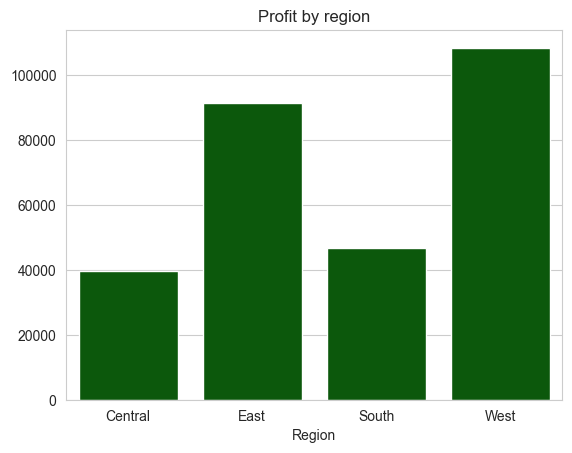

In [27]:
#Ganancia por región

region_profit = df.groupby("Region")["Profit"].sum()
sns.barplot (
    x = region_profit.index,
    y = region_profit.values,
    color = "darkgreen"
)


plt.title("Profit by region")
plt.show

Regional profitability analysis reveals notable differences in financial performance across markets. The West region generates the highest profit, indicating stronger operational efficiency and customer value, while lower-performing regions may face challenges related to product mix, pricing strategies, or discount levels. These results suggest that regional factors play a significant role in profitability and should be considered when developing growth and optimization strategies.

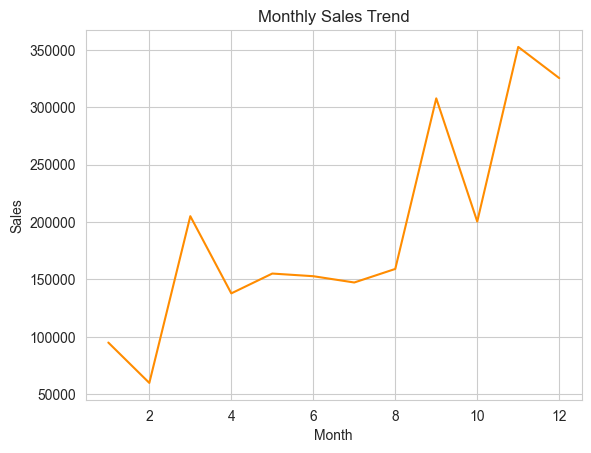

In [30]:
#ventas mensuales

df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby ("Month")["Sales"].sum()
plt.plot(monthly_sales.index, monthly_sales.values, color = "darkorange")

plt.title("Monthly Sales Trend")
plt.xlabel ("Month")
plt.ylabel("Sales")
plt.show()

Monthly sales analysis reveals fluctuations in revenue throughout the year, indicating that customer demand is not constant over time. These variations suggest the presence of seasonal patterns, promotional effects, or changing purchasing behavior. Monitoring sales trends at the monthly level helps identify peak-performing periods and supports more effective planning for inventory, marketing, and resource allocation.

Sales performance varies across months, highlighting the importance of understanding temporal trends. Identifying periods of high and low demand can help the business optimize operations, anticipate customer needs, and improve overall revenue performance.